In [1]:
import os
import subprocess
os.environ['LD_PRELOAD'] = '/usr/lib/x86_64-linux-gnu/libstdc++.so.6'
!pip install cvxpy --quiet
!pip install cvxopt --quiet


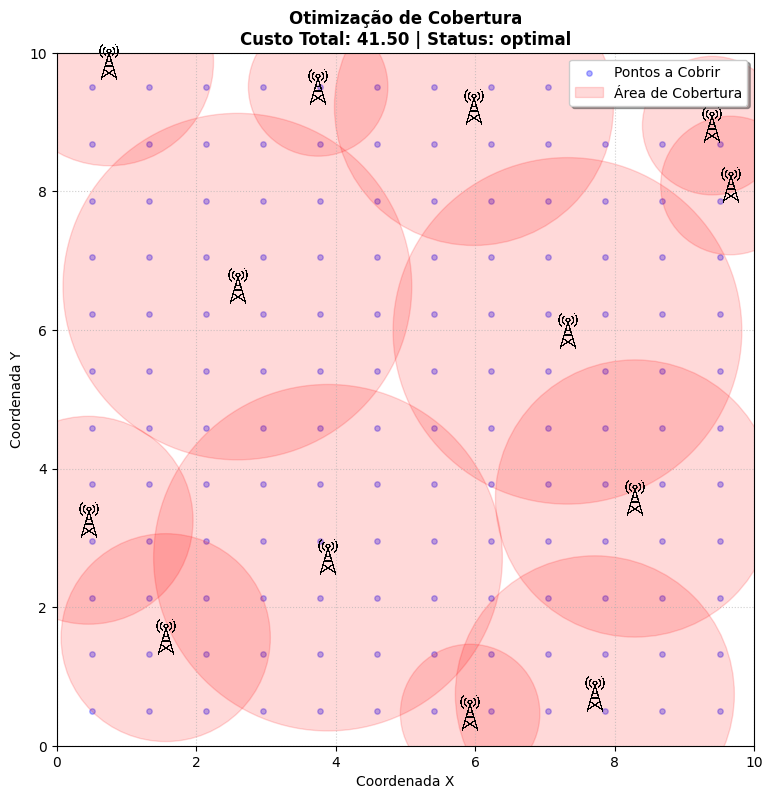

In [2]:
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import urllib.request # Para baixar o ícone (pode remover se já tiver a imagem)

# --- 1. Configurações ---
L = 10  #lado do quadrado
n_centros = 40          
raio_maximo = 2.5     
radii_candidates = [1, 1.5, 2, 2.5,] 

# Filtragem de raios
radii_candidates = [r for r in radii_candidates if r <= raio_maximo]

np.random.seed(42)
centers = np.random.rand(n_centros, 2) * L
all_centers, all_radii = [], []

for c in centers:
    for r in radii_candidates:
        all_centers.append(c)
        all_radii.append(r)

all_centers = np.array(all_centers)
all_radii = np.array(all_radii)

# --- 2. Grade de Pontos ---
x_grid = np.linspace(0.5, L-0.5, 12)
y_grid = np.linspace(0.5, L-0.5, 12)
X, Y = np.meshgrid(x_grid, y_grid)
points = np.vstack((X.flatten(), Y.flatten())).T

# --- 3. Matriz de Cobertura A ---
A = np.zeros((len(points), len(all_centers)))
for j, p in enumerate(points):
    dist = np.linalg.norm(all_centers - p, axis=1)
    A[j, :] = (dist <= all_radii).astype(int)

# --- 4. Otimização ---
x_var = cp.Variable(len(all_centers), boolean=True)
custo = all_radii**2 
prob = cp.Problem(cp.Minimize(custo @ x_var), [A @ x_var >= 1])
prob.solve(solver=cp.ECOS_BB)


antena_img = 'signal.png'

import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# --- 5. Plotagem Completa com Ícone Customizado ---
if x_var.value is not None:
    selected = np.where(x_var.value > 0.5)[0]
    fig, ax = plt.subplots(figsize=(9, 9)) 
    
    # 5.1. Plotar pontos da grade (Pontos a Cobrir)
    ax.scatter(points[:, 0], points[:, 1], c='blue', s=15, alpha=0.3, label='Pontos a Cobrir')
    
    # 5.2. Controle de Legenda
    antena_label_add = False
    cobertura_label_add = False
    
    # 5.3. Carregamento do Ícone do seu diretório
    caminho_do_icone = '/usr/app/MNDLZ-Analise1/signal.png'
    try:
        img_data = mpimg.imread(caminho_do_icone)
    except Exception as e:
        print(f"Aviso: Não foi possível carregar o ícone em {caminho_do_icone}. Erro: {e}")
        img_data = None

    for i in selected:
        # Área de Cobertura (Círculo)
        lbl_cob = 'Área de Cobertura' if not cobertura_label_add else ""
        circ = plt.Circle(all_centers[i], all_radii[i], color='red', alpha=0.15, ec='red', lw=1, label=lbl_cob)
        ax.add_patch(circ)
        cobertura_label_add = True
        
        # 5.4. Inserção do Ícone de Antena
        if img_data is not None:
            # DICA: Se o ícone estiver pequeno, aumente o zoom (ex: 0.08 ou 0.1)
            imagebox = OffsetImage(img_data, zoom=0.05) 
            ab = AnnotationBbox(imagebox, (all_centers[i, 0], all_centers[i, 1]), frameon=False)
            ax.add_artist(ab)
            
            # Ponto invisível para criar a entrada correta na legenda
            #if not antena_label_add:
                #ax.scatter(all_centers[i, 0], all_centers[i, 1], alpha=0, label='Local da Antena')
        else:
            # Fallback: Se a imagem falhar, desenha a cruz
            lbl_ant = 'Local da Antena' if not antena_label_add else ""
            ax.scatter(all_centers[i, 0], all_centers[i, 1], c='red', marker='x', s=60, label=lbl_ant)
        
        antena_label_add = True
        
    # 5.5. Configurações de Eixos e Título com CUSTO
    ax.set_xlim(0, L)
    ax.set_ylim(0, L)
    ax.set_title(f"Otimização de Cobertura\nCusto Total: {prob.value:.2f} | Status: {prob.status}", 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel("Coordenada X")
    ax.set_ylabel("Coordenada Y")
    
    # 5.6. Legenda e Grade
    ax.legend(loc='upper right', frameon=True, shadow=True)
    ax.grid(True, linestyle=':', alpha=0.6)
    plt.show()
else:
    print(f"Status: {prob.status}. O problema é inviável com as configurações atuais.")